In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Non-Gaussian Noise Analysis: Rayleigh and Gaussian-Chi

This tutorial demonstrates the implementation of a comprehensive non-Gaussian noise analysis toolkit in GWexpy, based on research by Yamamura (2024) and Yamamoto (2015-2016).

### Contents
1. **Noise Simulation**: Generating non-stationary and scattered light noise.
2. **Rayleigh Statistics**: Testing deviations from Rayleigh distribution.
3. **GauCh (Modified KS Test)**: Advanced non-Gaussianity detection.
4. **Student-t Indicator**: Measuring distribution tail thickness.
5. **Data Quality Flags**: Generating veto segments automatically.
6. **Evaluation & Visualization**: ROC curves and composite dashboards.

In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt

from gwexpy.noise import scatter_light_noise, transient_gaussian_noise
from gwexpy.plot.gauch_dashboard import plot_gauch_dashboard
from gwexpy.statistics import to_segments


## 1. Noise Simulation
We simulate two types of non-Gaussian noise models used in KAGRA characterization.
- **Model I**: Transient Gaussian noise (glitches).
- **Model II**: Scattered light noise (stationary non-Gaussianity).

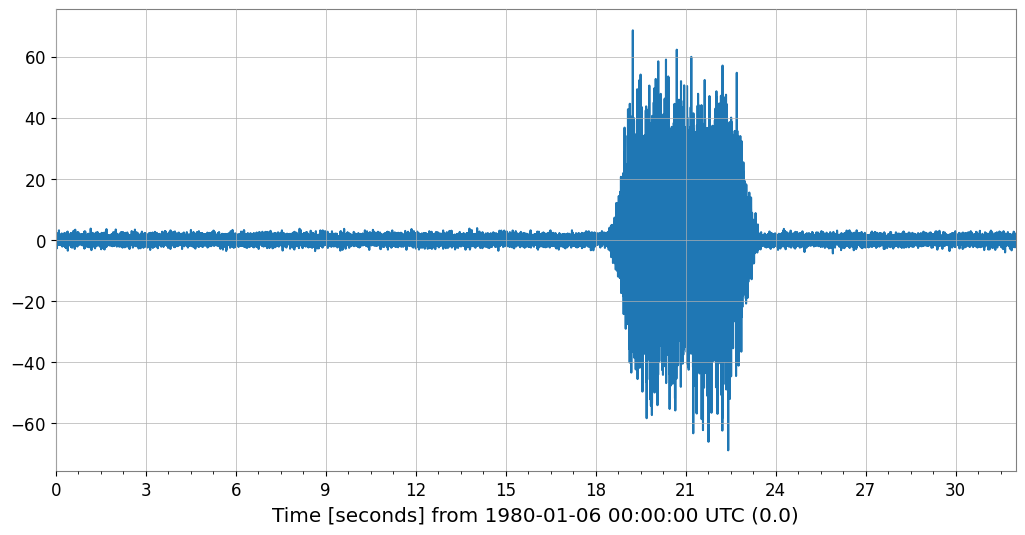

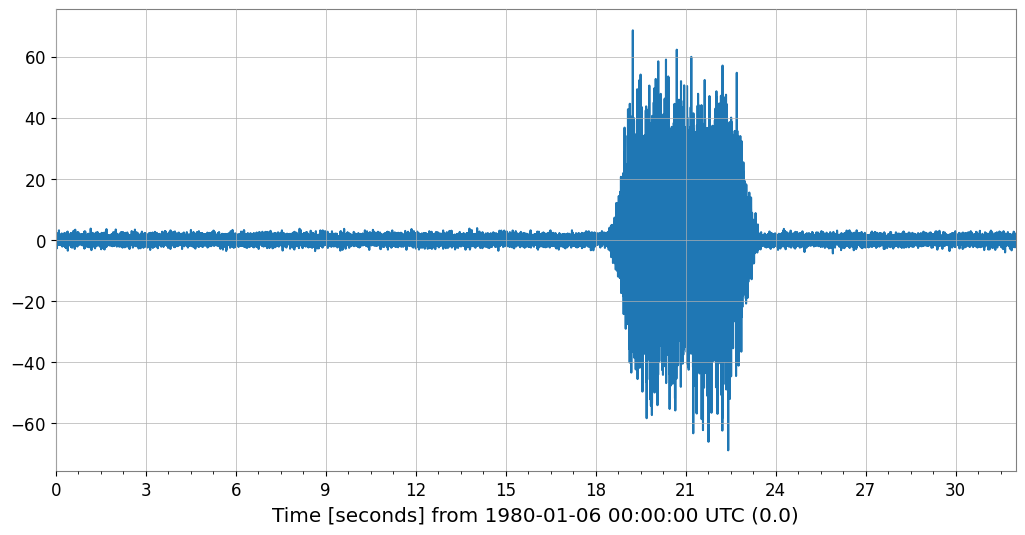

In [3]:
duration = 32.0
fs = 1024.0

# Model I: Glitch injection
ts_glitch = transient_gaussian_noise(duration, fs, A1=20.0, name='Glitchy Data')

# Model II: Scattered light
ts_scatter = scatter_light_noise(duration, fs, A2=1e-12, name='Scattered Light')

ts_glitch.plot()

## 2. Rayleigh Spectrogram
The Rayleigh statistic $R$ measures the consistency of the ASD distribution with a Rayleigh distribution. We use the `rayleigh_test` method to get a p-value map.

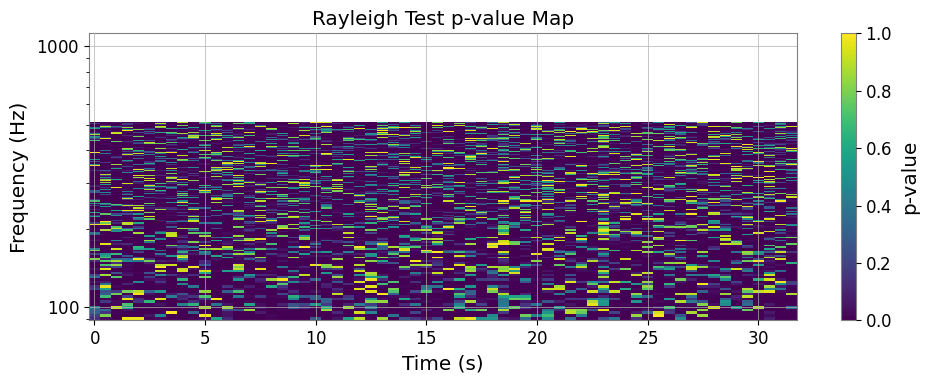

In [4]:
rs_p = ts_glitch.rayleigh_test(fftlength=0.4, stride=0.5, overlap=0.2, n_samples=20)
fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(rs_p.times.value, rs_p.frequencies.value, rs_p.value.T, shading='auto')
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Rayleigh Test p-value Map')
plt.colorbar(mappable=mesh, ax=ax, label='p-value')
plt.tight_layout()

## 3. GauCh (Modified KS Test)
GauCh is a more sensitive test for non-Gaussianity using a modified Kolmogorov-Smirnov test.

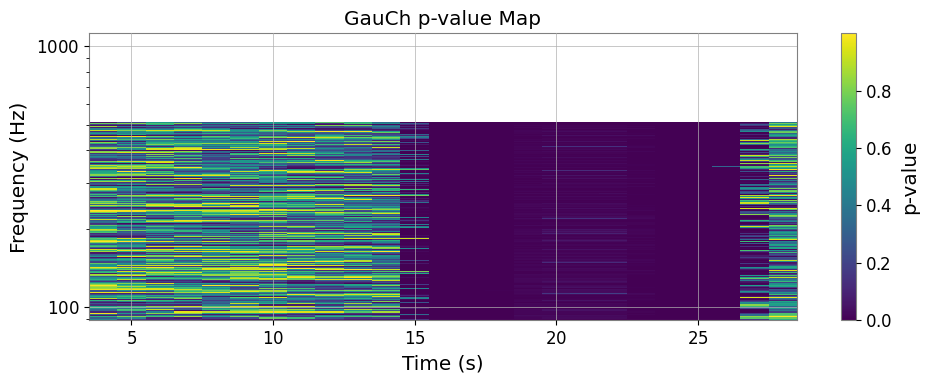

In [5]:
gauch_res = ts_glitch.gauch(fftlength=1.0, window=8)
fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(gauch_res.pvalue_map.times.value, gauch_res.pvalue_map.frequencies.value, gauch_res.pvalue_map.value.T, shading='auto')
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('GauCh p-value Map')
plt.colorbar(mappable=mesh, ax=ax, label='p-value')
plt.tight_layout()

## 4. Student-t Indicator
The Student-t indicator fits a Student-t distribution to FFT components and outputs the degree of freedom $\nu$.

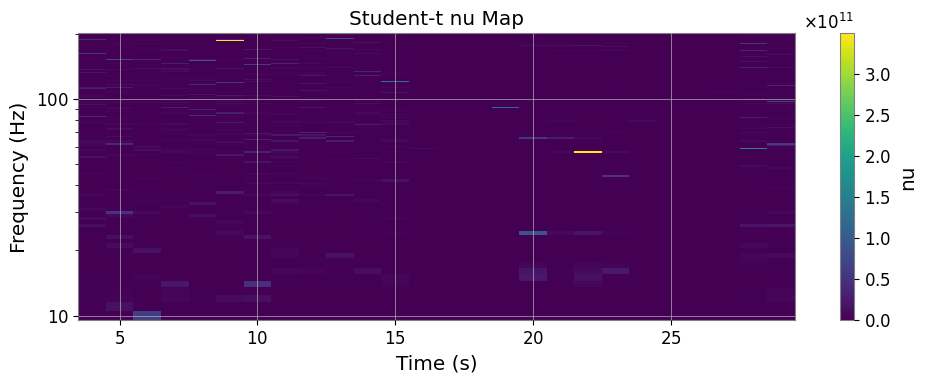

In [6]:
nu_spec = ts_glitch.student_t_spectrogram(fftlength=1.0, window=8, frange=(10, 200))
fig, ax = plt.subplots(figsize=(10, 4))
mesh = ax.pcolormesh(nu_spec.times.value, nu_spec.frequencies.value, nu_spec.value.T, shading='auto')
ax.set_yscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Student-t nu Map')
plt.colorbar(mappable=mesh, ax=ax, label='nu')
plt.tight_layout()

## 5. Data Quality Flags
We can automatically generate veto segments where the p-value is below a threshold.

<DataQualityFlag('non_gaussian_veto',
                 known=[[3.5 ... 28.5)]
                 active=[[14.5 ... 27.5)]
                 description='None')>


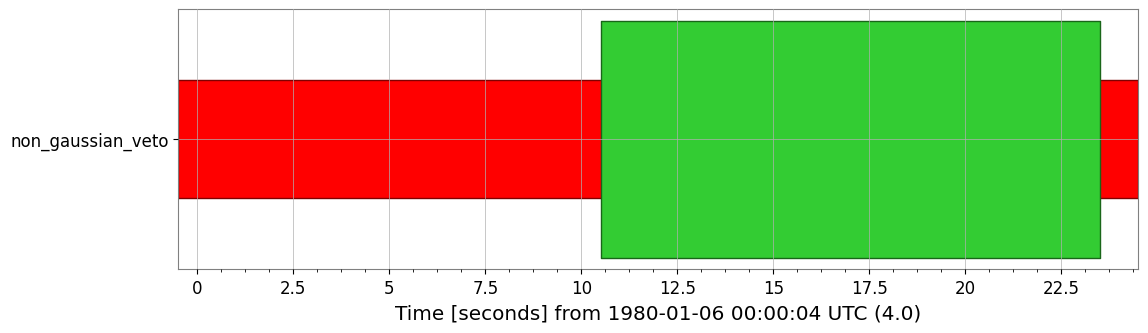

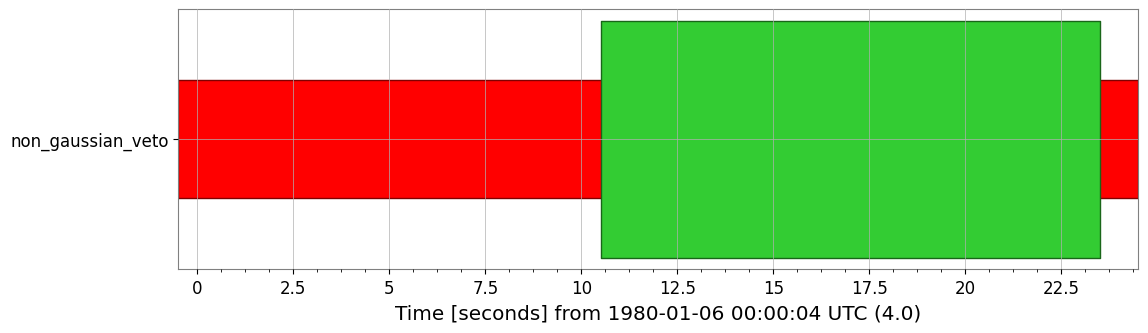

In [7]:
dq_flag = to_segments(gauch_res.pvalue_map, alpha=0.001)
print(dq_flag)
dq_flag.plot()

## 6. Composite Dashboard
Finally, we can visualize everything in a single dashboard.

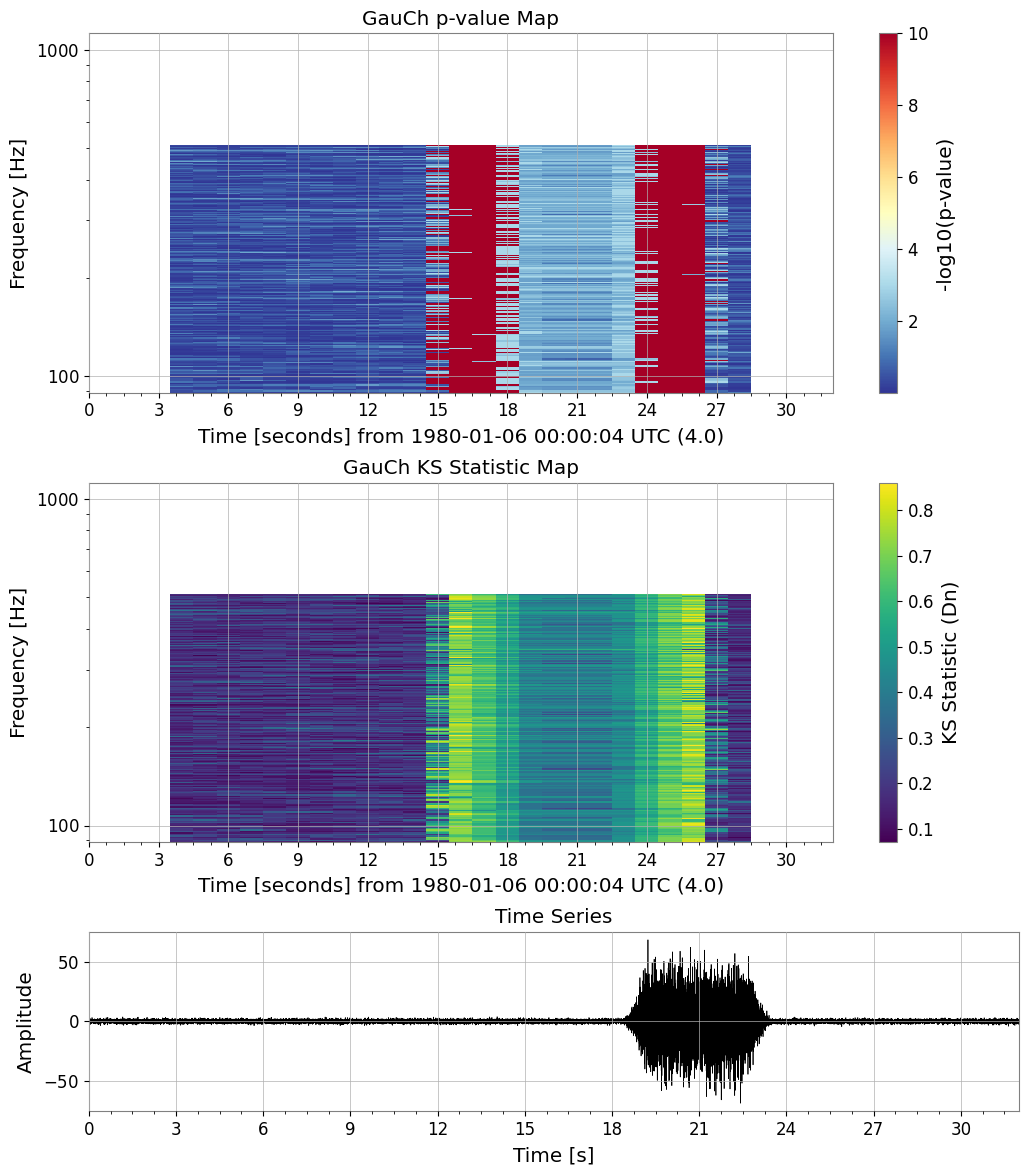

In [8]:
fig = plot_gauch_dashboard(ts_glitch, gauch_res)
plt.show()